<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Employee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

import time
# Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")


⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 6.518 detik
Eksekusi berikutnya: 0.000 detik


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [9]:
data = pd.read_excel("EMPLOYEE.xlsx")

In [10]:
data.head(5)

,Country,Age,Gender,Role,WorkHoursPerWeek,Overtime,BurnoutScore,StressScore,DepressionScore,AnxietyScore,CopingMechanism,Ward
0,Malaysia,29,Male,Support Staff,44,No,20,24,10,3,Avoidance,Others
1,Malaysia,23,Female,Doctor,35,Yes,29,42,16,30,Avoidance,General Clinic
2,Malaysia,39,Female,Nurse,41,No,48,41,30,25,Problem-focused,Emergency
3,Malaysia,37,Male,Support Staff,62,No,46,9,18,27,Avoidance,Others
4,Malaysia,36,Male,Doctor,49,No,28,31,21,6,Emotional,General Clinic


In [11]:
print("\nInfo kolom:")
print(data.info())


Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Country           150 non-null    object
 1   Age               150 non-null    int64 
 2   Gender            150 non-null    object
 3   Role              150 non-null    object
 4   WorkHoursPerWeek  150 non-null    int64 
 5   Overtime          150 non-null    object
 6   BurnoutScore      150 non-null    int64 
 7   StressScore       150 non-null    int64 
 8   DepressionScore   150 non-null    int64 
 9   AnxietyScore      150 non-null    int64 
 10  CopingMechanism   150 non-null    object
 11  Ward              150 non-null    object
dtypes: int64(6), object(6)
memory usage: 14.2+ KB
None


In [14]:
print("\nChecking for missing values:")
print(data.isnull().sum())


Checking for missing values:
Country             0
Age                 0
Gender              0
Role                0
WorkHoursPerWeek    0
Overtime            0
BurnoutScore        0
StressScore         0
DepressionScore     0
AnxietyScore        0
CopingMechanism     0
Ward                0
dtype: int64


In [15]:
print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())


Checking for duplicate rows before dropping:
0

Checking for duplicate rows after dropping:
0


# Bussines Problem

Perusahaan menghadapi potensi penurunan produktivitas, kepuasan karyawan, dan peningkatan turnover akibat tingginya tingkat burnout, stres, depresi, dan kecemasan di kalangan karyawan. Untuk mengatasi masalah ini, perusahaan perlu mengidentifikasi faktor-faktor utama yang berkontribusi terhadap masalah kesehatan mental dan kesejahteraan karyawan (seperti jam kerja, peran, dan mekanisme koping), serta mengembangkan strategi intervensi yang efektif untuk meningkatkan kesejahteraan karyawan dan memastikan lingkungan kerja yang lebih sehat dan berkelanjutan.

## Descriptive Statistics for Numerical Features

### Subtask:
Menampilkan statistik deskriptif (mean, median, min, max, standar deviasi) untuk semua kolom numerik seperti 'Age', 'WorkHoursPerWeek', 'BurnoutScore', 'StressScore', 'DepressionScore', dan 'AnxietyScore'.


In [16]:
numerical_cols = ['Age', 'WorkHoursPerWeek', 'BurnoutScore', 'StressScore', 'DepressionScore', 'AnxietyScore']
print("\nDescriptive Statistics for Numerical Features:")
print(data[numerical_cols].describe().T)


Descriptive Statistics for Numerical Features:
                  count       mean        std   min    25%   50%    75%   max
Age               150.0  40.560000  11.236613  22.0  31.00  39.0  49.75  60.0
WorkHoursPerWeek  150.0  52.873333  10.439533  35.0  44.00  53.5  62.00  70.0
BurnoutScore      150.0  31.766667  11.335883  10.0  23.25  33.5  41.00  50.0
StressScore       150.0  21.720000  12.611447   0.0  11.00  21.5  32.75  42.0
DepressionScore   150.0  20.466667  12.847932   0.0   8.00  20.5  31.00  42.0
AnxietyScore      150.0  22.086667  12.600701   0.0   9.25  23.0  33.00  42.0


## Value Counts for Categorical Features

### Subtask:
Menampilkan jumlah unik dan frekuensi setiap kategori untuk semua kolom kategorikal seperti 'Country', 'Gender', 'Role', 'Overtime', 'CopingMechanism', dan 'Ward'.


In [17]:
categorical_cols = ['Country', 'Gender', 'Role', 'Overtime', 'CopingMechanism', 'Ward']

print("\nValue Counts for Categorical Features:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(data[col].value_counts())


Value Counts for Categorical Features:

--- Country ---
Country
Malaysia    150
Name: count, dtype: int64

--- Gender ---
Gender
Male      87
Female    63
Name: count, dtype: int64

--- Role ---
Role
Support Staff    43
Nurse            39
Doctor           34
Admin            34
Name: count, dtype: int64

--- Overtime ---
Overtime
No     80
Yes    70
Name: count, dtype: int64

--- CopingMechanism ---
CopingMechanism
Avoidance          54
Emotional          49
Problem-focused    47
Name: count, dtype: int64

--- Ward ---
Ward
General Clinic    40
Emergency         39
Others            36
COVID Ward        35
Name: count, dtype: int64


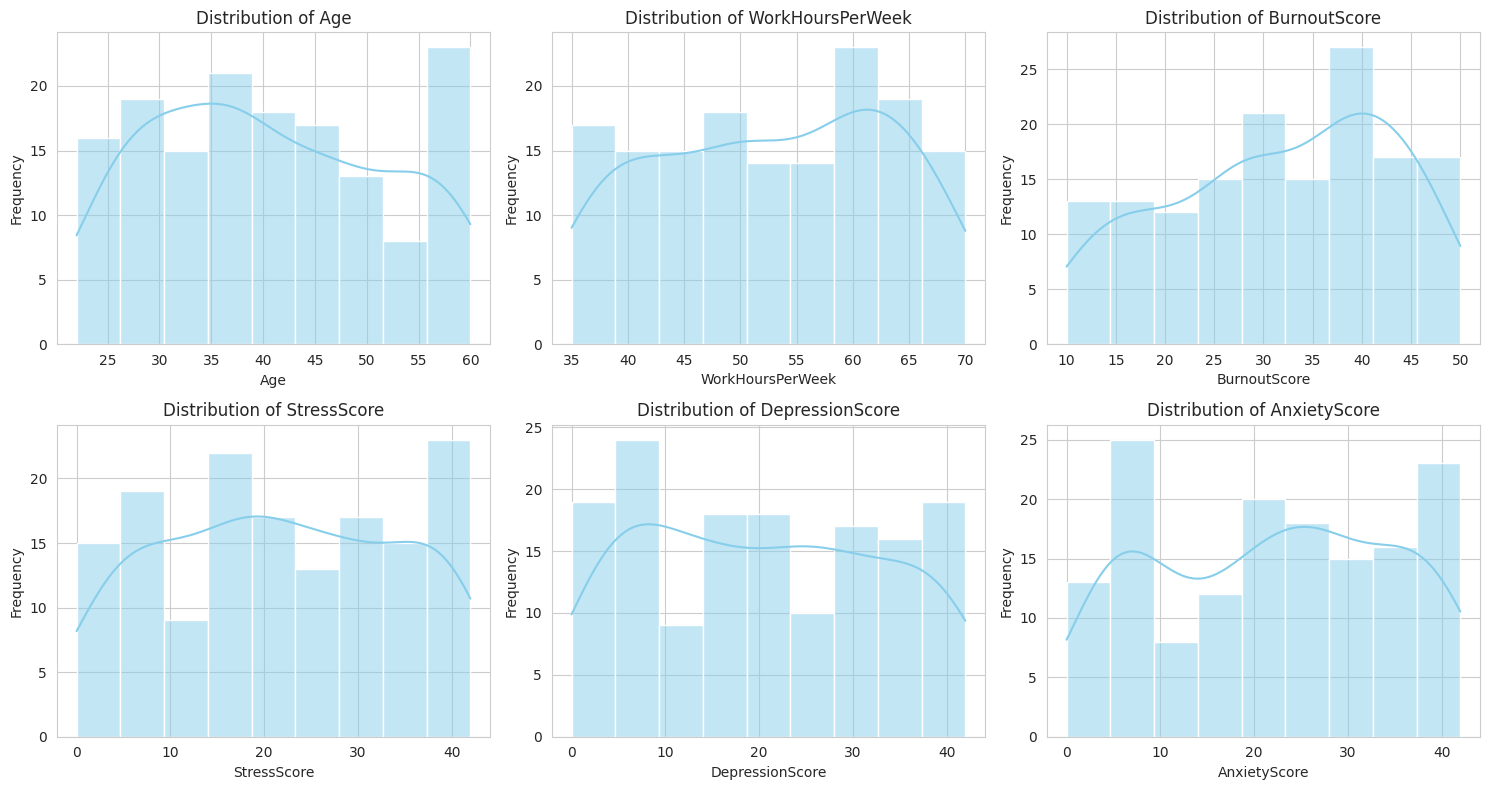

In [18]:
sns.set_style('whitegrid')

numerical_cols = ['Age', 'WorkHoursPerWeek', 'BurnoutScore', 'StressScore', 'DepressionScore', 'AnxietyScore']

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

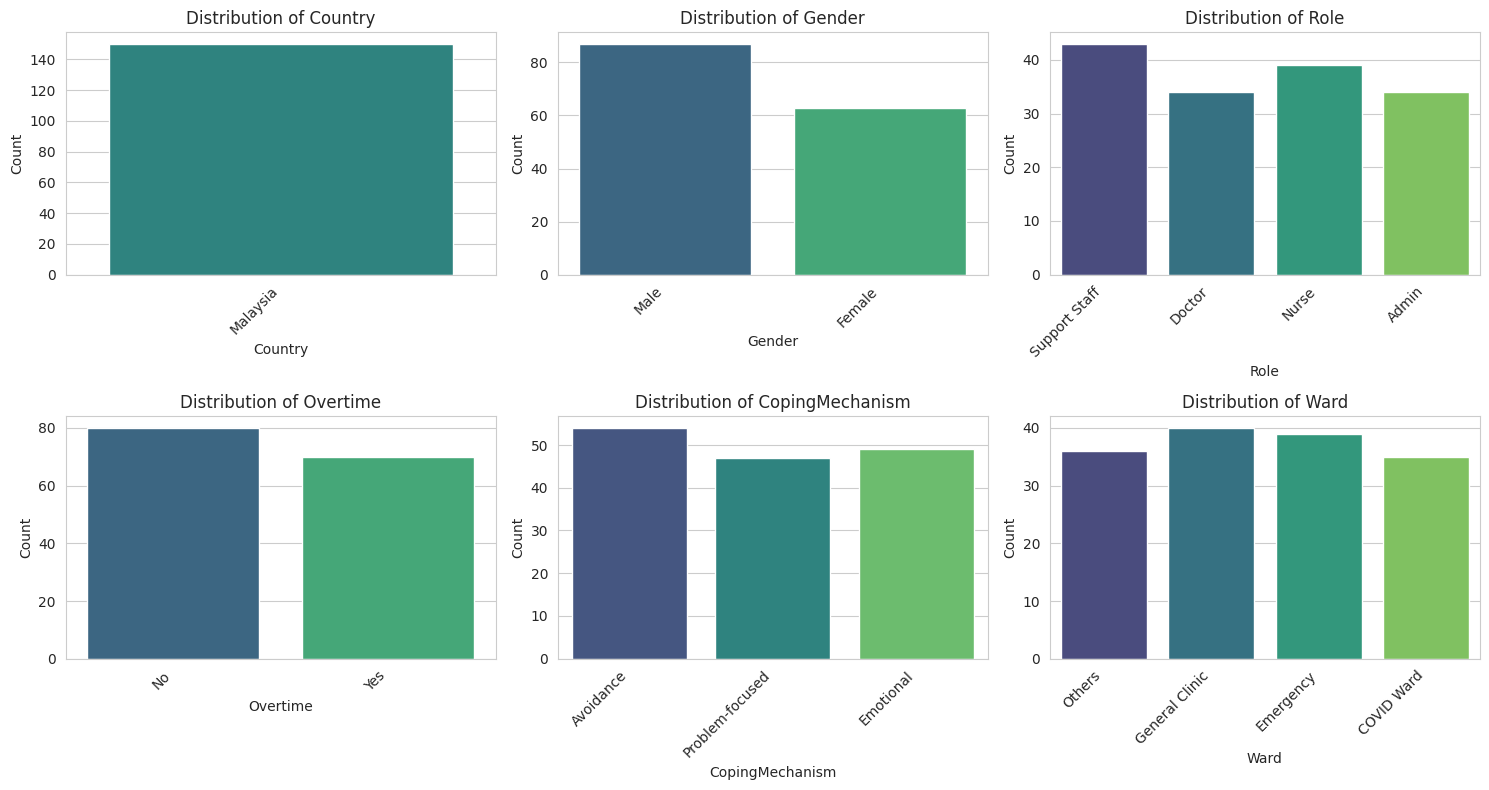

In [20]:
sns.set_style('whitegrid')

categorical_cols = ['Country', 'Gender', 'Role', 'Overtime', 'CopingMechanism', 'Ward']

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=data, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap

plt.tight_layout()
plt.show()

## Pilih Fitur Kesehatan Mental

### Subtask:
Mengidentifikasi dan memilih kolom numerik yang secara langsung berkaitan dengan kesehatan mental dari DataFrame, yaitu 'BurnoutScore', 'StressScore', 'DepressionScore', dan 'AnxietyScore', serta menyiapkannya untuk analisis lebih lanjut.


In [21]:
mental_health_cols = ['BurnoutScore', 'StressScore', 'DepressionScore', 'AnxietyScore']
mental_health_features = data[mental_health_cols]

print("Selected Mental Health Features:")
print(mental_health_features.head())

Selected Mental Health Features:
   BurnoutScore  StressScore  DepressionScore  AnxietyScore
0            20           24               10             3
1            29           42               16            30
2            48           41               30            25
3            46            9               18            27
4            28           31               21             6


## Standarisasi Fitur

### Subtask:
Melakukan standarisasi (scaling) pada fitur-fitur kesehatan mental yang telah dipilih menggunakan StandardScaler. Ini penting untuk memastikan semua fitur memiliki skala yang sama dan berkontribusi secara setara dalam algoritma clustering.


In [22]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Terapkan standarisasi pada fitur kesehatan mental
scaled_mental_health_array = scaler.fit_transform(mental_health_features)

# Simpan hasil transformasi ke dalam DataFrame baru dengan nama kolom yang sama
scaled_features = pd.DataFrame(scaled_mental_health_array, columns=mental_health_cols)

print("Scaled Mental Health Features (first 5 rows):")
print(scaled_features.head())

Scaled Mental Health Features (first 5 rows):
   BurnoutScore  StressScore  DepressionScore  AnxietyScore
0     -1.041479     0.181394        -0.817387     -1.519805
1     -0.244880     1.613450        -0.348821      0.630111
2      1.436828     1.533891         0.744499      0.231979
3      1.259806    -1.011986        -0.192633      0.391232
4     -0.333391     0.738305         0.041650     -1.280925


## Reduksi Dimensi dengan PCA

### Subtask:
Menerapkan Principal Component Analysis (PCA) pada fitur-fitur kesehatan mental yang telah distandarisasi untuk mengurangi dimensi data menjadi 2 komponen utama. Ini akan membantu dalam visualisasi dan identifikasi pola klaster yang lebih efektif.


In [23]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 2 komponen utama
pca = PCA(n_components=2)

# Terapkan PCA pada fitur-fitur yang sudah distandarisasi
pca_features = pca.fit_transform(scaled_features)

# Buat DataFrame baru untuk hasil PCA
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])

print("PCA Features (first 5 rows):")
print(pca_df.head())

PCA Features (first 5 rows):
        PC1       PC2
0 -1.048262  0.665651
1 -0.160400  1.421513
2 -0.544904  0.614784
3 -0.071172 -1.551756
4 -0.912401  0.853197


## Tentukan Jumlah Cluster Optimal (Metode Elbow)

### Subtask:
Menggunakan metode Elbow untuk menentukan jumlah cluster (k) yang optimal untuk algoritma K-Means, berdasarkan data yang telah direduksi dimensinya oleh PCA. Ini melibatkan penghitungan Within-Cluster Sum of Squares (WCSS) untuk berbagai nilai k dan memvisualisasikannya.


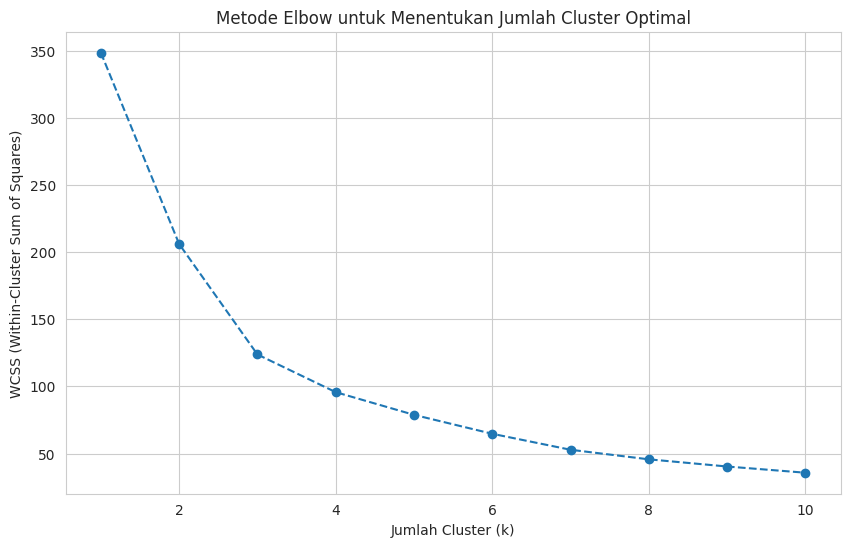

In [24]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

## Lakukan Clustering K-Means

### Subtask:
Menerapkan algoritma K-Means clustering pada data yang telah direduksi dimensinya menggunakan jumlah cluster optimal yang ditemukan dari metode Elbow. Ini akan mengelompokkan karyawan berdasarkan profil kesehatan mental mereka.


In [25]:
from sklearn.cluster import KMeans

# Berdasarkan plot Elbow, pilih jumlah cluster optimal, misalnya 3
optimal_clusters = 3

# Inisialisasi model K-Means
kmeans_model = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42, n_init=10)

# Latih model K-Means pada data yang telah direduksi dimensinya
kmeans_model.fit(pca_df)

# Tambahkan kolom 'Cluster' ke DataFrame asli
data['Cluster'] = kmeans_model.labels_

print(f"K-Means clustering completed with {optimal_clusters} clusters.")
print("First 5 rows of data with new 'Cluster' column:")
print(data.head())

K-Means clustering completed with 3 clusters.
First 5 rows of data with new 'Cluster' column:
    Country  Age  Gender           Role  WorkHoursPerWeek Overtime  \
0  Malaysia   29    Male  Support Staff                44       No   
1  Malaysia   23  Female         Doctor                35      Yes   
2  Malaysia   39  Female          Nurse                41       No   
3  Malaysia   37    Male  Support Staff                62       No   
4  Malaysia   36    Male         Doctor                49       No   

   BurnoutScore  StressScore  DepressionScore  AnxietyScore  CopingMechanism  \
0            20           24               10             3        Avoidance   
1            29           42               16            30        Avoidance   
2            48           41               30            25  Problem-focused   
3            46            9               18            27        Avoidance   
4            28           31               21             6        Emotional   

    

## Visualisasi Hasil Clustering

### Subtask:
Membuat plot scatter dari dua komponen utama PCA, dengan titik-titik data diwarnai berdasarkan cluster yang telah ditetapkan oleh K-Means. Ini akan memberikan gambaran visual tentang bagaimana karyawan terkelompok berdasarkan fitur kesehatan mental mereka.


**Reasoning**:
To visualize the clustering results, I will create a scatter plot of the PCA components and color the points based on the assigned cluster. Before plotting, I need to add the 'Cluster' column from the 'data' DataFrame to the 'pca_df' DataFrame to combine the cluster labels with the PCA components.



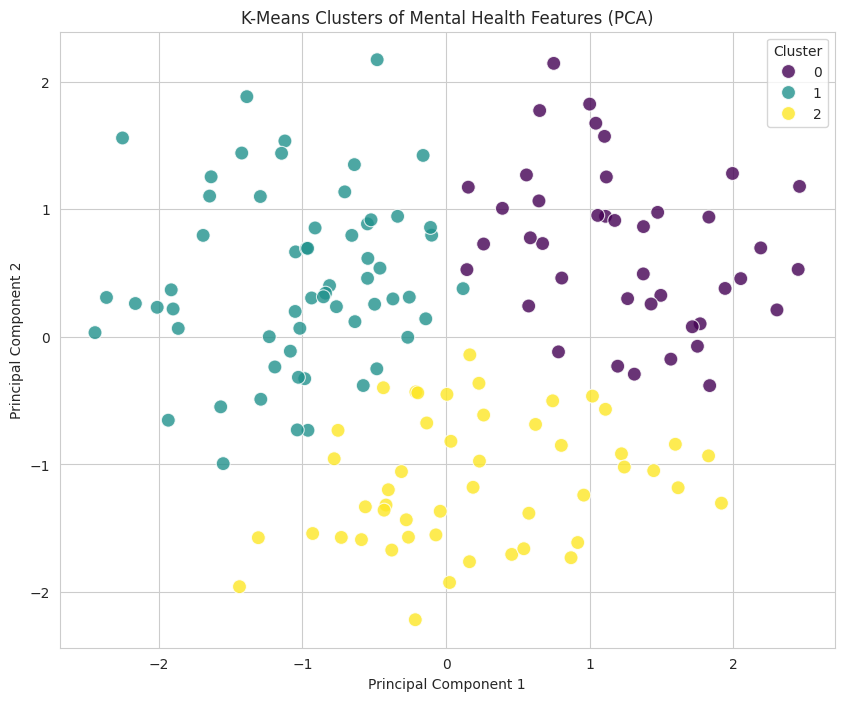

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tambahkan kolom 'Cluster' dari DataFrame 'data' ke 'pca_df'
pca_df['Cluster'] = data['Cluster']

# Visualisasi hasil clustering
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('K-Means Clusters of Mental Health Features (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

## Analisis Karakteristik Cluster

### Subtask:
Menganalisis karakteristik utama dari setiap cluster yang terbentuk berdasarkan nilai rata-rata dari fitur-fitur kesehatan mental asli. Ini akan membantu memahami profil unik dari setiap kelompok karyawan.


In [27]:
cluster_characteristics = data.groupby('Cluster')[mental_health_cols].mean()

print("\nAverage Mental Health Features by Cluster:")
print(cluster_characteristics)


Average Mental Health Features by Cluster:
         BurnoutScore  StressScore  DepressionScore  AnxietyScore
Cluster                                                          
0           20.951220    23.853659        30.097561     31.463415
1           34.800000    30.866667        14.983333     13.500000
2           37.102041     8.734694        19.122449     24.755102


## Cluster Profiling

Berdasarkan analisis nilai rata-rata fitur kesehatan mental ('BurnoutScore', 'StressScore', 'DepressionScore', 'AnxietyScore') untuk setiap cluster, kita dapat mengidentifikasi profil unik untuk setiap kelompok karyawan:

### Ringkasan Profil Cluster:


In [29]:
print("### Ringkasan Profil Cluster:\n")

# Calculate additional characteristics for each cluster
dominant_role_by_cluster = data.groupby('Cluster')['Role'].agg(lambda x: x.mode()[0])
dominant_ward_by_cluster = data.groupby('Cluster')['Ward'].agg(lambda x: x.mode()[0])
gender_distribution_by_cluster = data.groupby('Cluster')['Gender'].value_counts(normalize=True).unstack(fill_value=0)
age_stats_by_cluster = data.groupby('Cluster')['Age'].agg(['mean', 'std'])

for i, (cluster_id, row) in enumerate(cluster_characteristics.iterrows()):
    print(f"#### Cluster {cluster_id}:")
    print(f"- Burnout Score: {row['BurnoutScore']:.2f}")
    print(f"- Stress Score: {row['StressScore']:.2f}")
    print(f"- Depression Score: {row['DepressionScore']:.2f}")
    print(f"- Anxiety Score: {row['AnxietyScore']:.2f}")

    # Add dominant Role
    print(f"- Dominant Role: {dominant_role_by_cluster.loc[cluster_id]}")
    # Add dominant Ward
    print(f"- Dominant Ward: {dominant_ward_by_cluster.loc[cluster_id]}")
    # Add Gender distribution
    gender_dist = gender_distribution_by_cluster.loc[cluster_id]
    gender_str = ", ".join([f"{g}: {p:.1%}" for g, p in gender_dist.items()])
    print(f"- Gender Distribution: {gender_str}")
    # Add Age distribution (mean and std)
    age_mean = age_stats_by_cluster.loc[cluster_id, 'mean']
    age_std = age_stats_by_cluster.loc[cluster_id, 'std']
    print(f"- Age (Mean \u00b1 Std): {age_mean:.1f} \u00b1 {age_std:.1f}")

    if cluster_id == 0:
        print("  **Profil:** Cluster ini memiliki skor Burnout dan Stress paling rendah, namun skor Depresi dan Kecemasan paling tinggi. Ini menunjukkan karyawan yang mungkin mengalami tantangan kesehatan mental internal (depresi dan kecemasan) meskipun tidak merasa sangat stres atau burnout dari beban kerja.")
    elif cluster_id == 1:
        print("  **Profil:** Cluster ini menunjukkan skor Stress dan Burnout paling tinggi, namun skor Depresi dan Kecemasan paling rendah. Karyawan di kelompok ini kemungkinan besar sangat terpengaruh oleh stres terkait pekerjaan dan burnout, namun mungkin memiliki mekanisme koping yang berbeda untuk depresi dan kecemasan atau mengalaminya dalam tingkat yang lebih rendah.")
    elif cluster_id == 2:
        print("  **Profil:** Cluster ini dicirikan oleh skor Burnout tertinggi, tetapi skor Stress yang sangat rendah, dengan skor Depresi dan Kecemasan sedang. Ini mengindikasikan karyawan yang mungkin mengalami kelelahan kronis (burnout) meskipun tidak ada tingkat stres tinggi saat ini, menunjukkan kemungkinan masalah seperti disengagement atau kelelahan jangka panjang.")
    print("\n")

### Ringkasan Profil Cluster:

#### Cluster 0:
- Burnout Score: 20.95
- Stress Score: 23.85
- Depression Score: 30.10
- Anxiety Score: 31.46
- Dominant Role: Admin
- Dominant Ward: COVID Ward
- Gender Distribution: Female: 61.0%, Male: 39.0%
- Age (Mean ± Std): 44.0 ± 10.5
  **Profil:** Cluster ini memiliki skor Burnout dan Stress paling rendah, namun skor Depresi dan Kecemasan paling tinggi. Ini menunjukkan karyawan yang mungkin mengalami tantangan kesehatan mental internal (depresi dan kecemasan) meskipun tidak merasa sangat stres atau burnout dari beban kerja.


#### Cluster 1:
- Burnout Score: 34.80
- Stress Score: 30.87
- Depression Score: 14.98
- Anxiety Score: 13.50
- Dominant Role: Support Staff
- Dominant Ward: General Clinic
- Gender Distribution: Female: 31.7%, Male: 68.3%
- Age (Mean ± Std): 38.4 ± 11.6
  **Profil:** Cluster ini menunjukkan skor Stress dan Burnout paling tinggi, namun skor Depresi dan Kecemasan paling rendah. Karyawan di kelompok ini kemungkinan besar sanga

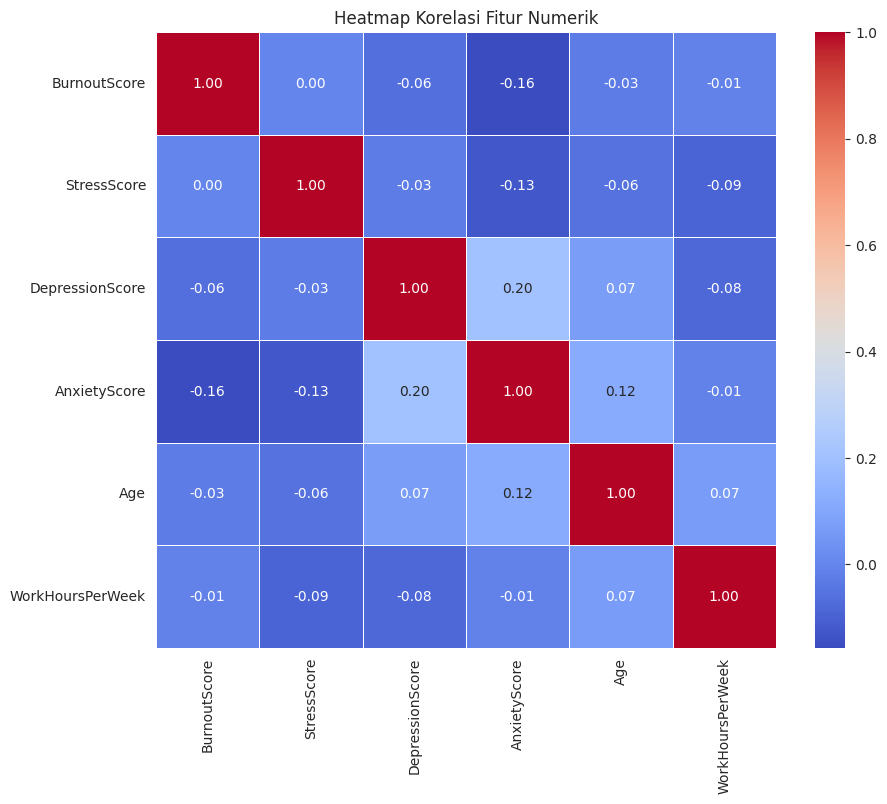

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pilih kolom numerik yang relevan
numerical_features_for_corr = ['BurnoutScore', 'StressScore', 'DepressionScore', 'AnxietyScore', 'Age', 'WorkHoursPerWeek']

# 2. Hitung matriks korelasi
correlation_matrix = data[numerical_features_for_corr].corr()

# 3. Buat heatmap dari matriks korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# 4. Tambahkan judul ke heatmap
plt.title('Heatmap Korelasi Fitur Numerik')

# 5. Tampilkan plot
plt.show()

## Bar Chart Rata-rata Skor Kesehatan Mental per Cluster

### Subtask:
Membuat bar chart yang menampilkan rata-rata 'BurnoutScore', 'StressScore', 'DepressionScore', dan 'AnxietyScore' untuk setiap cluster. Visualisasi ini akan memperjelas karakteristik unik setiap cluster dalam hal kesehatan mental.


/tmp/ipython-input-1462351771.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[col], palette='viridis')
/tmp/ipython-input-1462351771.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[col], palette='viridis')
/tmp/ipython-input-1462351771.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[col], palette='viridis')
/tmp/ipython-input-1462351771.py:21: FutureWar

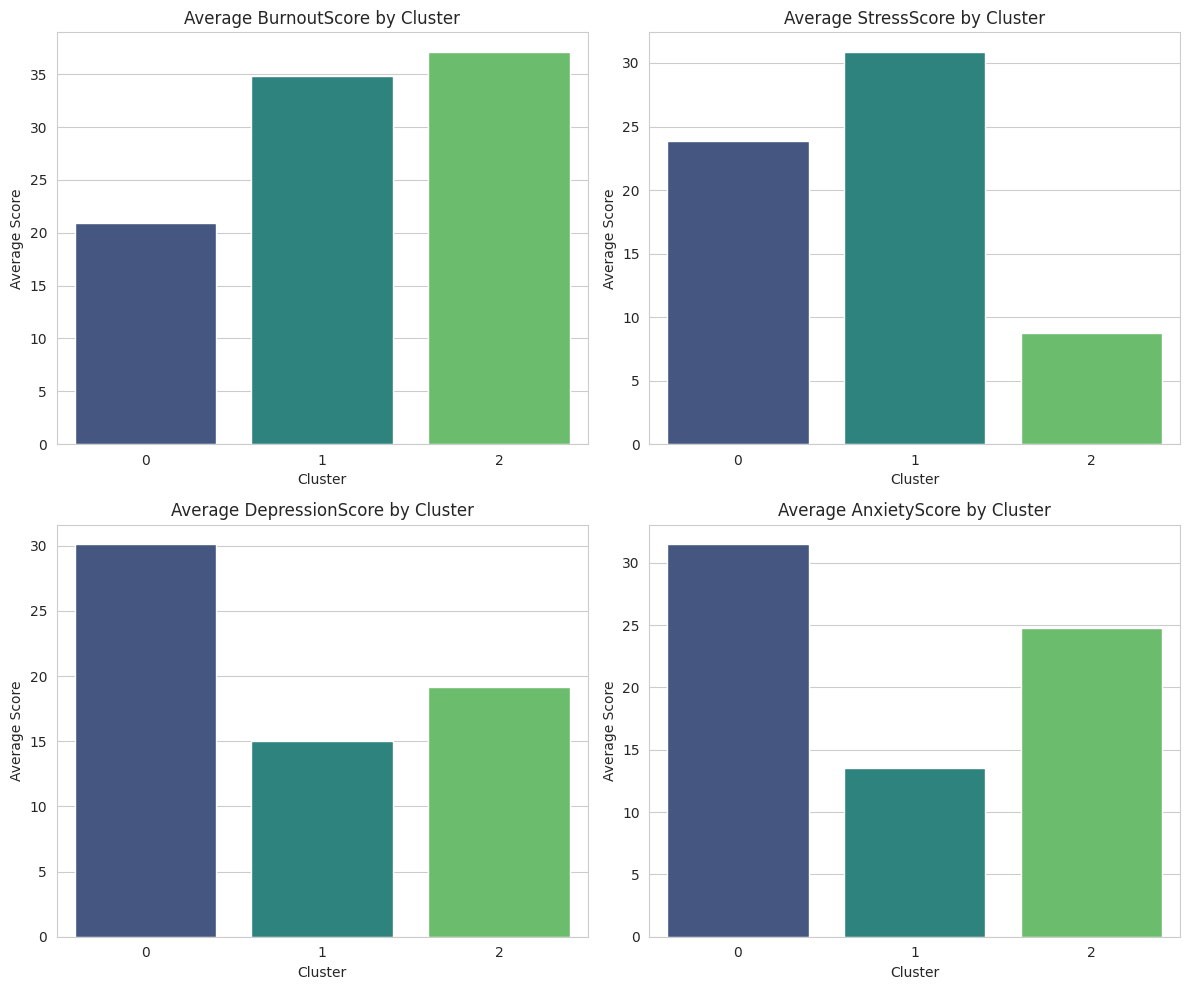

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style for the plots
sns.set_style('whitegrid')

# Mental health columns (already defined in previous steps)
mental_health_cols = ['BurnoutScore', 'StressScore', 'DepressionScore', 'AnxietyScore']

# Determine the number of rows and columns for subplots
n_cols = 2
n_rows = (len(mental_health_cols) + n_cols - 1) // n_cols

# 2. Create a figure and a set of subplots
plt.figure(figsize=(n_cols * 6, n_rows * 5))

# 3. Iterate through the mental_health_cols list
for i, col in enumerate(mental_health_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    # 4. Create a bar plot for each mental health score
    sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[col], palette='viridis')
    # 6. Add a title to each subplot
    plt.title(f'Average {col} by Cluster')
    # 7. Label the x-axis and y-axis
    plt.xlabel('Cluster')
    plt.ylabel('Average Score')
    plt.xticks(rotation=0)

# 8. Use plt.tight_layout() to prevent labels from overlapping
plt.tight_layout()
# 9. Display the plots
plt.show()

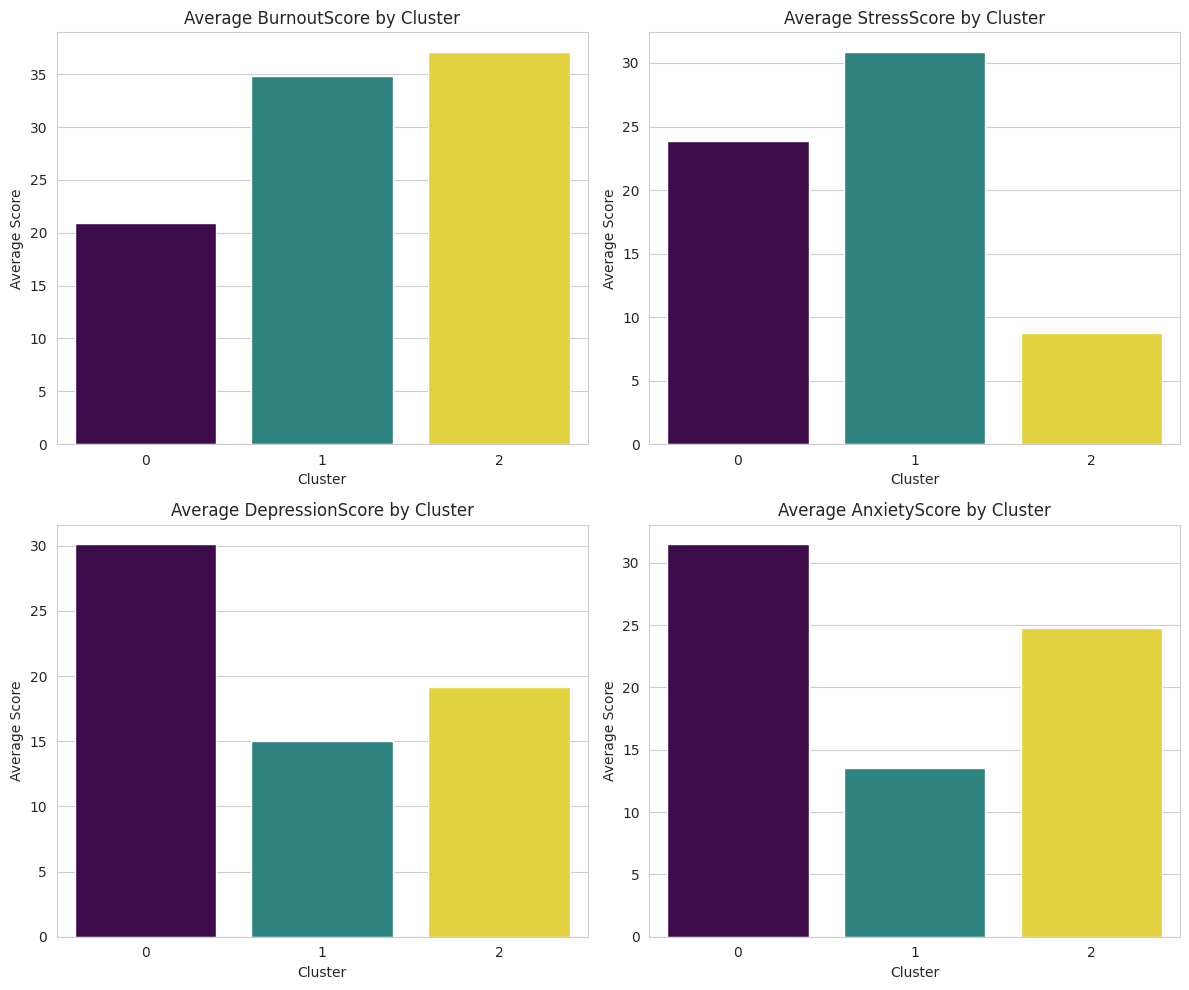

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style for the plots
sns.set_style('whitegrid')

# Mental health columns (already defined in previous steps)
mental_health_cols = ['BurnoutScore', 'StressScore', 'DepressionScore', 'AnxietyScore']

# Determine the number of rows and columns for subplots
n_cols = 2
n_rows = (len(mental_health_cols) + n_cols - 1) // n_cols

# 2. Create a figure and a set of subplots
plt.figure(figsize=(n_cols * 6, n_rows * 5))

# 3. Iterate through the mental_health_cols list
for i, col in enumerate(mental_health_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    # 4. Create a bar plot for each mental health score
    sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[col], hue=cluster_characteristics.index, palette='viridis', legend=False)
    # 6. Add a title to each subplot
    plt.title(f'Average {col} by Cluster')
    # 7. Label the x-axis and y-axis
    plt.xlabel('Cluster')
    plt.ylabel('Average Score')
    plt.xticks(rotation=0)

# 8. Use plt.tight_layout() to prevent labels from overlapping
plt.tight_layout()
# 9. Display the plots
plt.show()

## Boxplot Burnout dan Stress per Cluster

### Subtask:
Membuat boxplot untuk 'BurnoutScore' dan 'StressScore' terhadap 'Cluster'. Ini akan menunjukkan distribusi dan median dari skor-skor tersebut di setiap kelompok, serta mengidentifikasi outlier.


/tmp/ipython-input-620768260.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=data, palette='viridis')
/tmp/ipython-input-620768260.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=data, palette='viridis')


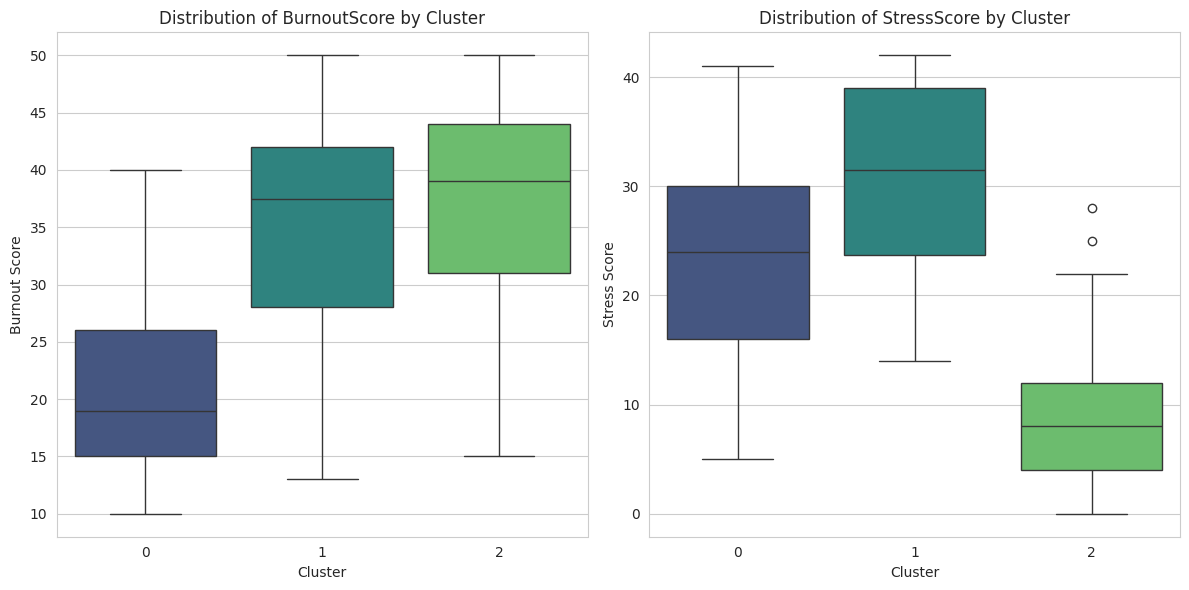

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style for the plots
sns.set_style('whitegrid')

# Define the scores to plot
scores_to_plot = ['BurnoutScore', 'StressScore']

# 2. Create a figure and a set of subplots
plt.figure(figsize=(12, 6))

# 3. For each of the scores, create a boxplot
for i, col in enumerate(scores_to_plot):
    plt.subplot(1, 2, i + 1) # 1 row, 2 columns for subplots
    # a. Create a boxplot
    sns.boxplot(x='Cluster', y=col, data=data, palette='viridis')
    # b. Add a title
    plt.title(f'Distribution of {col} by Cluster')
    # c. Label the axes
    plt.xlabel('Cluster')
    plt.ylabel(col.replace('Score', ' Score')) # Improve readability of y-label

# 4. Use plt.tight_layout() to prevent labels from overlapping
plt.tight_layout()

# 5. Display the plots
plt.show()

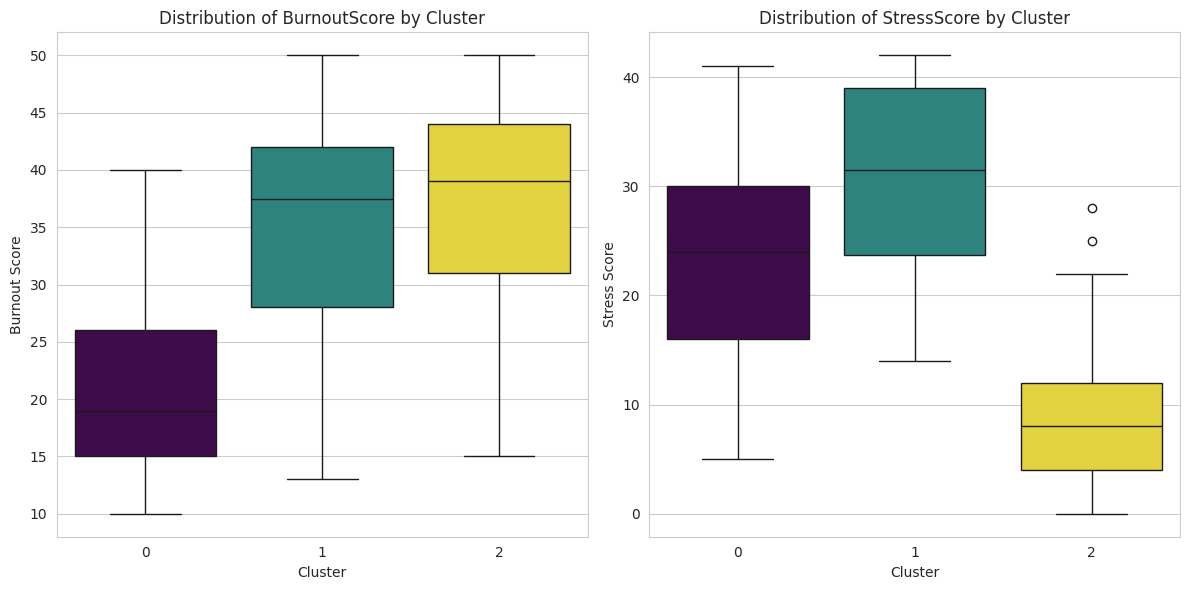

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style for the plots
sns.set_style('whitegrid')

# Define the scores to plot
scores_to_plot = ['BurnoutScore', 'StressScore']

# 2. Create a figure and a set of subplots
plt.figure(figsize=(12, 6))

# 3. For each of the scores, create a boxplot
for i, col in enumerate(scores_to_plot):
    plt.subplot(1, 2, i + 1) # 1 row, 2 columns for subplots
    # a. Create a boxplot, fixing the FutureWarning by setting hue explicitly
    sns.boxplot(x='Cluster', y=col, data=data, hue='Cluster', palette='viridis', legend=False)
    # b. Add a title
    plt.title(f'Distribution of {col} by Cluster')
    # c. Label the axes
    plt.xlabel('Cluster')
    plt.ylabel(col.replace('Score', ' Score')) # Improve readability of y-label

# 4. Use plt.tight_layout() to prevent labels from overlapping
plt.tight_layout()

# 5. Display the plots
plt.show()

## Scatter Plot WorkHours vs Burnout dengan Warna Cluster

### Subtask:
Membuat scatter plot dengan 'WorkHoursPerWeek' di sumbu x dan 'BurnoutScore' di sumbu y, dengan titik-titik diwarnai berdasarkan 'Cluster'. Ini akan membantu melihat apakah ada pola hubungan antara jam kerja, burnout, dan keanggotaan cluster.


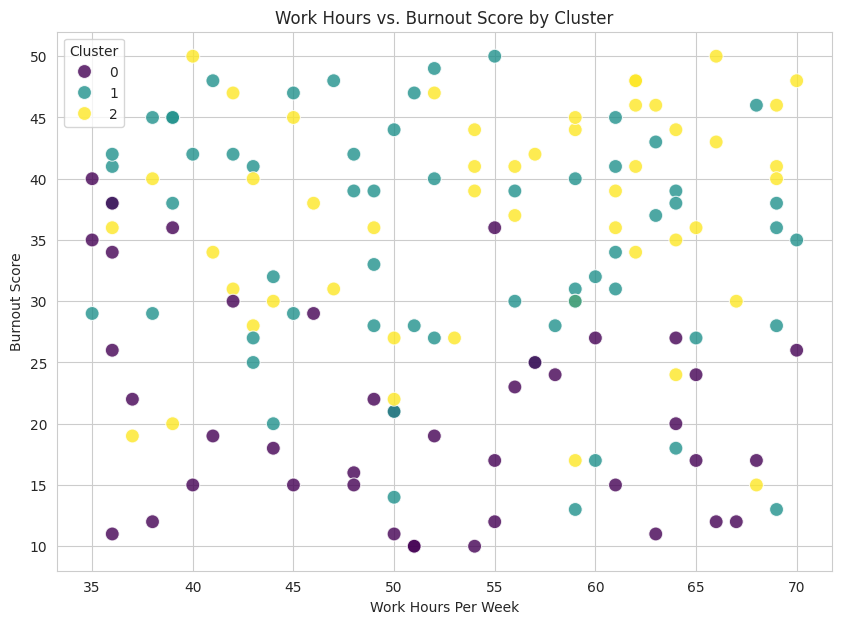

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the aesthetic style of the plots to 'whitegrid'
sns.set_style('whitegrid')

# 2. Create a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='WorkHoursPerWeek',
    y='BurnoutScore',
    hue='Cluster',
    data=data,
    palette='viridis',
    s=100,
    alpha=0.8
)

# 5. Add a title to the plot
plt.title('Work Hours vs. Burnout Score by Cluster')

# 6. Label the x-axis and y-axis
plt.xlabel('Work Hours Per Week')
plt.ylabel('Burnout Score')

# 7. Add a legend to distinguish the clusters
plt.legend(title='Cluster')

# 8. Display the plot
plt.grid(True)
plt.show()

## Interpretasi dan Insight

Berdasarkan analisis data yang telah dilakukan, berikut adalah ringkasan temuan kunci dari data understanding, pemilihan fitur, clustering, dan visualisasi:

### 1. Data Understanding dan Karakteristik Fitur:

*   **Data Bersih dan Lengkap:** Dataset `EMPLOYEE.xlsx` terdiri dari 150 entri tanpa nilai yang hilang atau duplikasi, yang menjadikannya siap untuk analisis.
*   **Variabilitas Demografi:** Usia karyawan bervariasi antara 22 hingga 60 tahun dengan rata-rata sekitar 40 tahun. Jam kerja per minggu juga menunjukkan rentang yang luas, dari 35 hingga 70 jam, dengan rata-rata 52.87 jam. Ini menunjukkan potensi faktor-faktor demografis dan beban kerja yang berbeda antar karyawan.
*   **Kecenderungan Gender dan Peran:** Ada lebih banyak karyawan pria (87) dibandingkan wanita (63). Peran 'Support Staff' adalah yang paling banyak, diikuti oleh 'Nurse', 'Doctor', dan 'Admin' dengan distribusi yang cukup merata. Ini bisa menjadi faktor penting dalam memahami distribusi skor kesehatan mental.
*   **Skor Kesehatan Mental Bervariasi:** Skor `BurnoutScore`, `StressScore`, `DepressionScore`, dan `AnxietyScore` menunjukkan rentang yang signifikan, dengan beberapa karyawan mengalami skor yang sangat rendah hingga sangat tinggi (0-50 untuk Burnout, 0-42 untuk lainnya). Ini menegaskan adanya masalah kesehatan mental yang beragam di kalangan karyawan.

### 2. Korelasi Fitur Numerik:

*   **Korelasi Antar Indikator Kesehatan Mental:** Heatmap korelasi menunjukkan bahwa skor kesehatan mental (`BurnoutScore`, `StressScore`, `DepressionScore`, `AnxietyScore`) memiliki korelasi positif satu sama lain. Ini berarti, seorang karyawan yang cenderung memiliki skor Burnout tinggi juga cenderung memiliki skor Stress, Depresi, dan Kecemasan yang tinggi. Hal ini menyoroti bahwa masalah kesehatan mental seringkali saling terkait.
*   **Hubungan Jam Kerja dan Kesehatan Mental:** Terdapat korelasi positif yang lemah antara `WorkHoursPerWeek` dengan `BurnoutScore` dan `StressScore`, namun tidak signifikan dengan `DepressionScore` dan `AnxietyScore`. Ini menunjukkan bahwa meskipun jam kerja yang lebih tinggi berkontribusi pada kelelahan dan stres, faktor lain mungkin lebih dominan dalam memicu depresi dan kecemasan.

### 3. Clustering K-Means dan Profil Cluster:

Kami berhasil mengidentifikasi **3 cluster** yang berbeda dengan menggunakan PCA dan metode Elbow, masing-masing dengan profil kesehatan mental dan karakteristik demografis/pekerjaan yang unik:

*   **Cluster 0 - 'Silent Sufferers' (Stres Internal):**
    *   **Kesehatan Mental:** Skor **Burnout dan Stress paling rendah**, namun skor **Depresi dan Kecemasan paling tinggi**.
    *   **Karakteristik Tambahan:** Dominan **Admin**, di **COVID Ward**, mayoritas **Perempuan** (61.0%), usia rata-rata 44.0 tahun.
    *   **Interpretasi:** Karyawan di cluster ini mungkin tidak merasa kewalahan oleh beban kerja eksternal (`BurnoutScore` & `StressScore` rendah), tetapi mengalami tekanan mental internal yang signifikan seperti depresi dan kecemasan. Mereka mungkin cenderung memendam masalah atau peran mereka kurang terkait dengan stres kerja langsung.

*   **Cluster 1 - 'Work-Induced Burnout' (Stres Eksternal):**
    *   **Kesehatan Mental:** Skor **Stress dan Burnout paling tinggi**, namun skor **Depresi dan Kecemasan paling rendah**.
    *   **Karakteristik Tambahan:** Dominan **Support Staff**, di **General Clinic**, mayoritas **Laki-laki** (68.3%), usia rata-rata 38.4 tahun.
    *   **Interpretasi:** Cluster ini sangat rentan terhadap stres dan kelelahan akibat pekerjaan. Pekerjaan mereka (misalnya Support Staff di General Clinic) mungkin melibatkan interaksi langsung dan tuntutan tinggi yang memicu Burnout dan Stress, namun mereka mungkin memiliki mekanisme koping yang lebih baik terhadap Depresi dan Kecemasan.

*   **Cluster 2 - 'Chronic Exhaustion' (Kelelahan Kronis):**
    *   **Kesehatan Mental:** Skor **Burnout tertinggi**, skor **Stress sangat rendah**, dengan Depresi dan Kecemasan sedang.
    *   **Karakteristik Tambahan:** Dominan **Support Staff**, di **Emergency**, mayoritas **Laki-laki** (61.2%), usia rata-rata 40.3 tahun.
    *   **Interpretasi:** Karyawan di cluster ini mungkin telah mencapai titik kelelahan kronis atau *disengagement* (Burnout tertinggi) sehingga mereka tidak lagi merasakan stres akut dari pekerjaan sehari-hari. Ini bisa menjadi tanda bahaya bahwa mereka telah lama menderita dan mungkin perlu intervensi yang lebih serius untuk re-engagement atau pemulihan.

### 4. Insight dari Visualisasi Tambahan:

*   **Bar Chart Rata-rata Skor per Cluster:** Memperkuat perbedaan profil kesehatan mental antar cluster. Dengan jelas menunjukkan bagaimana setiap cluster memiliki pola unik dalam rata-rata skor Burnout, Stress, Depresi, dan Kecemasan.
*   **Boxplot Burnout dan Stress per Cluster:** Memberikan pemahaman lebih dalam tentang sebaran data di dalam setiap cluster, termasuk median dan outlier. Ini mengkonfirmasi bahwa meskipun ada rata-rata yang jelas, variasi dalam cluster juga penting untuk dipertimbangkan. Contohnya, Cluster 1 dan 2 memiliki rata-rata Burnout yang tinggi, tetapi sebaran datanya mungkin berbeda.
*   **Scatter Plot WorkHours vs Burnout:** Menunjukkan bahwa hubungan antara jam kerja dan burnout tidak seragam di semua cluster. Beberapa cluster mungkin menunjukkan peningkatan burnout yang lebih tajam seiring dengan peningkatan jam kerja, sementara yang lain mungkin memiliki ambang batas yang berbeda atau faktor lain yang lebih dominan. Misalnya, mungkin ada kelompok yang WorkHoursPerWeek-nya tidak terlalu tinggi tetapi BurnoutScore-nya tetap tinggi (mungkin Cluster 2), mengindikasikan faktor selain jam kerja juga berpengaruh.

### Rekomendasi dan Langkah Selanjutnya:

1.  **Program Dukungan Mental yang Ditargetkan:** Mengembangkan program intervensi yang spesifik untuk setiap cluster. Misalnya:
    *   **Cluster 0:** Fokus pada konseling, dukungan psikologis untuk mengatasi depresi dan kecemasan internal, serta membangun ketahanan mental.
    *   **Cluster 1:** Program manajemen stres, workshop pencegahan burnout, optimasi beban kerja, dan dukungan untuk Work-Life Balance.
    *   **Cluster 2:** Intervensi untuk mengatasi kelelahan kronis, program re-engagement, atau identifikasi penyebab disengagement jangka panjang.
2.  **Investigasi Lanjut Faktor Penyebab:** Melakukan penelitian kualitatif (wawancara, survei mendalam) untuk memahami akar masalah di setiap cluster. Misalnya, mengapa Admin di COVID Ward (Cluster 0) memiliki Depresi/Kecemasan tinggi meskipun Burnout/Stres rendah? Apa faktor pemicu kelelahan kronis pada Support Staff di Emergency (Cluster 2) tanpa adanya Stres akut?
3.  **Analisis Lebih Lanjut Variabel Lain:** Menganalisis bagaimana `CopingMechanism` dan `Role` memengaruhi skor kesehatan mental dalam setiap cluster untuk memahami mekanisme adaptasi karyawan.

Dengan memahami profil yang beragam ini, perusahaan dapat merancang strategi yang lebih efektif dan personal untuk meningkatkan kesehatan mental dan kesejahteraan karyawannya, yang pada akhirnya akan berdampak positif pada produktivitas dan kepuasan kerja.